# 🎮 **Predicting Video Game Sales** 💰

**CMSC 320 - Spring 2026 Final Project Tutorial**

### **Contributions**
|**Member**|**Sections**|**Summary**|
|------|-----|-----|
|Amulya| A, B, C, G|Contributed to initial idea; worked on T-Testing for part C; wrote final tutorial |
|Leann|A, B, C, F|Contributed to initial idea; worked on ANOVA tests in part C; worked on data visualizations|
|Luke|A, B, C, D, E|Contributed to initial idea; designed prediction model and machine learning workflow|
|Neha|A, B, C, F|Contributed to initial idea; worked on ANOVA tests in part C; worked on data visualizations|
|Richard|A, B, C, F|Contributed to initial idea; worked on Chi Square tests for part C; worked on descriptions and analysis|

In [28]:
# ===== Imports ========================

import pandas as pd
import numpy as np
import re

# Imports for hypothesis testing

from scipy.stats import f_oneway
import matplotlib.pyplot as plt
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from scipy.stats import chi2_contingency
from scipy.stats import ttest_ind

# Imports for machine learning and data processing

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.compose import TransformedTargetRegressor
from sklearn.dummy import DummyRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    median_absolute_error
)
from sklearn.base import BaseEstimator, TransformerMixin

In [29]:
# ===== Loading CSV & .describe() ========================

df = pd.read_csv("vgsales.csv")
df.describe(include='all')

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
count,16598.000000,16598,16598,16327.000000,16598,16540,16598.000000,16598.000000,16598.000000,16598.000000,16598.000000
unique,NaN,11493,31,NaN,12,578,NaN,NaN,NaN,NaN,NaN
top,NaN,Need for Speed: Most Wanted,DS,NaN,Action,Electronic Arts,NaN,NaN,NaN,NaN,NaN
freq,NaN,12,2163,NaN,3316,1351,NaN,NaN,NaN,NaN,NaN
mean,8300.605254,NaN,NaN,2006.406443,NaN,NaN,0.264667,0.146652,0.077782,0.048063,0.537441
std,4791.853933,NaN,NaN,5.828981,NaN,NaN,0.816683,0.505351,0.309291,0.188588,1.555028
min,1.000000,NaN,NaN,1980.000000,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.010000
25%,4151.250000,NaN,NaN,2003.000000,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.060000
50%,8300.500000,NaN,NaN,2007.000000,NaN,NaN,0.080000,0.020000,0.000000,0.010000,0.170000
75%,12449.750000,NaN,NaN,2010.000000,NaN,NaN,0.240000,0.110000,0.040000,0.040000,0.470000


Rank: 0 outliers
Year: 305 outliers
NA_Sales: 1681 outliers
EU_Sales: 2081 outliers
JP_Sales: 2425 outliers
Other_Sales: 1665 outliers
Global_Sales: 1893 outliers


<Axes: >

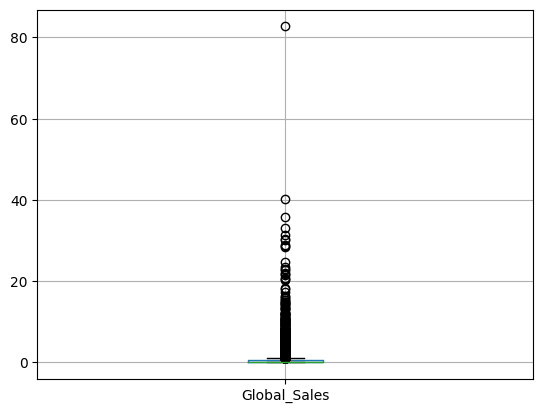

In [30]:
numeric_cols = ["Rank", "Year", "NA_Sales", "EU_Sales", "JP_Sales", "Other_Sales", "Global_Sales"]

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"{col}: {len(outliers)} outliers")
df.boxplot(column="Global_Sales")

# Several things can be noted about the data using .describe().

*   There are 11 features to this data, with 7 numerical and 4 string.
*   Almost all games have publishers, with the most common being Electronic Arts
*   There are 16598 games, yet only 11493 unique names. Some games appear multiple times as they are republished on different platforms
*   This data does not represent buyer demographic, only sales
*   Action is the most common genre with around 20% total
*   With mean games of 2006 and a span of 40 years starting in 1980, the number of games released increases with time.
*   NA, EU, and JP sales make up the bulk of global sales and the ratio created by these sales is consistent
*   The top game, Wii Sports, laps the next best selling by a factor of 2 and is the biggest outlier of the set.




# **Data Cleaning**

We noticed that some of the entries had the same game name on the same platform. Hence, to clean up the data, we removed duplicate entries. We also recognize that some of the rows do not have a value for year or publisher. Since we do not actively use entries with no value for year/publisher during our hypothesis tests, it is safe to remove them.


In [31]:
# printing the duplicates
duplicates = df[df.duplicated(subset=['Name','Platform','Year'], keep=False)]
print("Duplicates:")
print(duplicates)
print()

# printing out the columns with null values
print("Columns with null values:")
print(df.isnull().sum())

# dropping the rows with missing Publisher (not used in tests, keeps data clean)
df = df.dropna(subset=['Publisher'])

# dropping the rows with missing Publisher (not used in tests, keeps data clean)
df = df.dropna(subset=['Year'])

# remove the duplicates
df = df.drop_duplicates(subset=['Name','Platform','Year'])

Duplicates:
        Rank                         Name Platform    Year    Genre  \
603      604                Madden NFL 13      PS3  2012.0   Sports   
14997  15000  Wii de Asobu: Metroid Prime      Wii     NaN  Shooter   
14999  15002  Wii de Asobu: Metroid Prime      Wii     NaN  Shooter   
16127  16130                Madden NFL 13      PS3  2012.0   Sports   

             Publisher  NA_Sales  EU_Sales  JP_Sales  Other_Sales  \
603    Electronic Arts      2.11      0.23      0.00         0.22   
14997         Nintendo      0.00      0.00      0.02         0.00   
14999         Nintendo      0.00      0.00      0.02         0.00   
16127  Electronic Arts      0.00      0.01      0.00         0.00   

       Global_Sales  
603            2.56  
14997          0.02  
14999          0.02  
16127          0.01  

Columns with null values:
Rank              0
Name              0
Platform          0
Year            271
Genre             0
Publisher        58
NA_Sales          0
EU_Sales 

In [32]:
df.dtypes

,0
Rank,int64
Name,object
Platform,object
Year,float64
Genre,object
Publisher,object
NA_Sales,float64
EU_Sales,float64
JP_Sales,float64
Other_Sales,float64


- ANOVA: genre vs. global_sales
- T-test: newer vs older games sales (use median)
- Chi square: genre vs. platform

# **ANOVA Testing: Genre vs Global Sales**

The hypotheses for the ANOVA test will be:

$H_0$ = The mean global sales are equal across all genres.

$H_A$ = At least one genre has a different mean global sales than the others.

We will test this using $α$ = 0.05.

In [33]:
# getting all of the genres
genres = df["Genre"].unique()

# since it is anova test, we need them in groups
groups = []
for g in genres:
    data = df[df["Genre"] == g]["Global_Sales"] # global sales for each genre
    groups.append(data)

f_stat, p_value = f_oneway(*groups) # running anova for each genre

print("f-statistic:", f_stat)
print("p-value:", p_value)

f-statistic: 18.176251874552776
p-value: 1.3349239855922282e-36


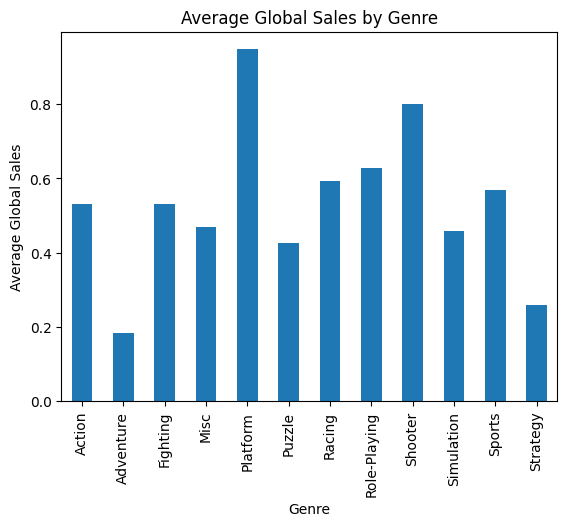

In [34]:
means = df.groupby("Genre")["Global_Sales"].mean()

means.plot(kind="bar")

plt.xlabel("Genre")
plt.ylabel("Average Global Sales")
plt.title("Average Global Sales by Genre")
plt.show()

In [35]:
tukey = pairwise_tukeyhsd(
    endog=df['Global_Sales'],
    groups=df['Genre'],
    alpha=0.05
)

print(tukey)

      Multiple Comparison of Means - Tukey HSD, FWER=0.05       
   group1       group2    meandiff p-adj   lower   upper  reject
----------------------------------------------------------------
      Action    Adventure  -0.3458    0.0 -0.5142 -0.1774   True
      Action     Fighting   0.0012    1.0 -0.1963  0.1987  False
      Action         Misc  -0.0615 0.9775 -0.2143  0.0914  False
      Action     Platform   0.4176    0.0  0.2236  0.6116   True
      Action       Puzzle   -0.105 0.9452 -0.3363  0.1263  False
      Action       Racing   0.0633 0.9881 -0.1074  0.2341  False
      Action Role-Playing   0.0985 0.6858 -0.0616  0.2586  False
      Action      Shooter   0.2705    0.0  0.1025  0.4385   True
      Action   Simulation  -0.0701 0.9914 -0.2665  0.1263  False
      Action       Sports   0.0385 0.9991 -0.1002  0.1773  False
      Action     Strategy  -0.2713 0.0024 -0.4874 -0.0552   True
   Adventure     Fighting    0.347    0.0  0.1203  0.5737   True
   Adventure         Misc

**ANOVA Conclusion:** We conducted an ANOVA test to see if video game genres  affected average global sales. Since the p-value is less than the alpha value 0.05, the results show a significant effect of genre on global sales, indicating that at least one genre has a different mean sales value.

We wanted to further investigate which genres differ, so we performed a pairwise Tukey HSD post-hoc test. The results showed several significant pairwise differences between genres. For example, Platform and Shooter games consistently showed significantly higher average global sales compared to lower-performing genres like Adventure, Strategy, and Puzzle (all p < 0.05), which shows they had high global sales.

On the other hand, Adventure and Strategy genres had significantly lower sales compared to many other genres, including Action, Shooter, and Racing. Some genres (Action vs. Fighting, Racing vs. Sports, and Role-Playing vs. Simulation) did not have a p-value < 0.05, indicating that they performed similarly in terms of sales.

Overall, the ANOVA and Post-hoc tests confirm that genre plays a significant role in influencing global sales performance.


# **Chi-Square Testing: Genre vs Platform**

In [36]:
contingency_table = pd.crosstab(df['Genre'], df['Platform'])
contingency_table

Platform,2600,3DO,3DS,DC,DS,GB,GBA,GC,GEN,GG,...,SAT,SCD,SNES,TG16,WS,Wii,WiiU,X360,XB,XOne
Genre,,,,,,,,,,,,,,,,,,,,,
Action,55,0,180,3,335,6,162,98,3,0,...,3,0,12,0,0,230,63,318,152,68
Adventure,1,1,36,11,238,5,36,20,2,0,...,26,0,4,1,0,83,3,47,26,12
Fighting,1,0,14,12,36,0,23,42,5,0,...,31,0,25,0,0,41,5,65,44,7
Misc,5,0,53,0,389,8,86,35,1,0,...,15,2,17,0,0,272,21,122,45,15
Platform,9,0,28,2,89,18,139,73,7,1,...,5,1,26,0,0,57,16,24,49,4
Puzzle,8,1,19,0,236,15,39,12,0,0,...,5,0,13,0,0,54,4,6,7,0
Racing,4,0,10,6,66,2,64,60,1,0,...,8,1,9,0,0,92,3,102,122,19
Role-Playing,0,0,85,4,196,21,73,25,3,0,...,17,1,50,0,4,35,6,75,23,13
Shooter,22,0,6,3,42,1,40,48,1,0,...,22,0,10,1,0,61,10,197,124,33


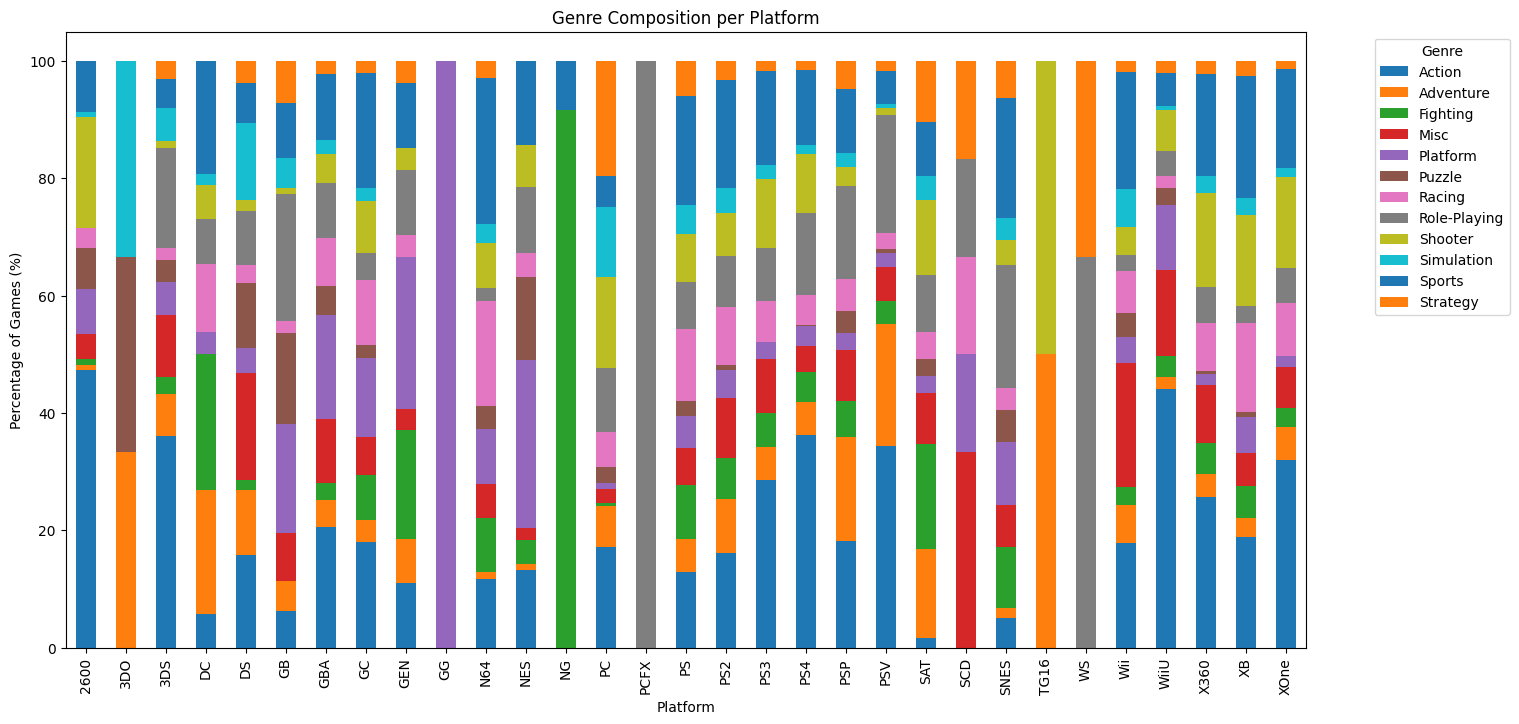

In [37]:
# calculating percentages of each genre per platform
percentages_table = contingency_table.div(contingency_table.sum(axis=0), axis=1) * 100

# transposing table to make platforms the x-axis
percentages_table = percentages_table.T

# creating stacked bar chart to visualize composition
percentages_table.plot(kind='bar', stacked=True, figsize=(16, 8), title='Genre Composition per Platform')
plt.xlabel('Platform')
plt.ylabel('Percentage of Games (%)')

plt.legend(title='Genre', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

The hypotheses for the chi-square test will be:

$H_0$ = The game genre and game platform are independent from each other.

$H_A$ = The game genre and game platform are dependent on each other.

We will test this using $α$ = 0.05.

In [38]:
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print("chi-square statistic:", chi2)
print("p-value:", p_value)

chi-square statistic: 5841.636273391987
p-value: 0.0


**Chi-square conclusion:** Since the p-value = 0.0 < $α$ = 0.05, we can conclude that there is a very strong association that the type of genre and the type of platform are dependent on each other.

# **T-Test: New vs Old Games**

In [39]:
# Running T-test for each region's sales

# old games (group 1) are those made from 1980-1999 (NA)
old_games_NA = df[df['Year'] < 2000]['NA_Sales']
# new games (group 2) are those made from 2000-2016 (NA)
new_games_NA = df[df['Year'] >= 2000]['NA_Sales']
t_stat_NA, p_value_NA = ttest_ind(old_games_NA, new_games_NA, equal_var=False)

# old games (group 1) are those made from 1980-1999 (EU)
old_games_EU = df[df['Year'] < 2000]['EU_Sales']
# new games (group 2) are those made from 2000-2016 (EU)
new_games_EU = df[df['Year'] >= 2000]['EU_Sales']
t_stat_EU, p_value_EU = ttest_ind(old_games_EU, new_games_EU, equal_var=False)

# old games (group 1) are those made from 1980-1999 (JP)
old_games_JP = df[df['Year'] < 2000]['JP_Sales']
# new games (group 2) are those made from 2000-2016 (JP)
new_games_JP = df[df['Year'] >= 2000]['JP_Sales']
t_stat_JP, p_value_JP = ttest_ind(old_games_JP, new_games_JP, equal_var=False)

# old games (group 1) are those made from 1980-1999 (Other)
old_games_other = df[df['Year'] < 2000]['Other_Sales']
# new games (group 2) are those made from 2000-2016 (Other)
new_games_other = df[df['Year'] >= 2000]['Other_Sales']
t_stat_other, p_value_other = ttest_ind(old_games_other, new_games_other, equal_var=False)

# sum of the rows for the old year range games (used for Hypothesis Testing)
sum_old_games = old_games_NA + old_games_EU + old_games_JP + old_games_other
# sum of the rows for the new year range games (used for Hypothesis Testing)
sum_new_games = new_games_NA + new_games_EU + new_games_JP + new_games_other
t_stat_total, p_value_total = ttest_ind(sum_old_games, sum_new_games, equal_var=False)

print("NA T-Statistic: ", t_stat_NA, "NA P-Value:", p_value_NA)
print("EU T-Statistic: ", t_stat_EU, "EU P-Value:", p_value_EU)
print("JP T-Statistic: ", t_stat_JP, "JP P-Value:", p_value_JP)
print("Other T-Statistic: ", t_stat_other, "Other P-Value:", p_value_other)
print("Total T-Statistic:", t_stat_total, "Total P-Value:", p_value_total)

NA T-Statistic:  5.343007374437312 NA P-Value: 1.011756325258651e-07
EU T-Statistic:  1.1603173858060958 EU P-Value: 0.24602150562498828
JP T-Statistic:  14.273231151679008 JP P-Value: 3.6398963172483555e-44
Other T-Statistic:  -9.934908961640927 Other P-Value: 4.203017913504549e-23
Total T-Statistic: 6.918653019434493 Total P-Value: 5.9243822453190935e-12


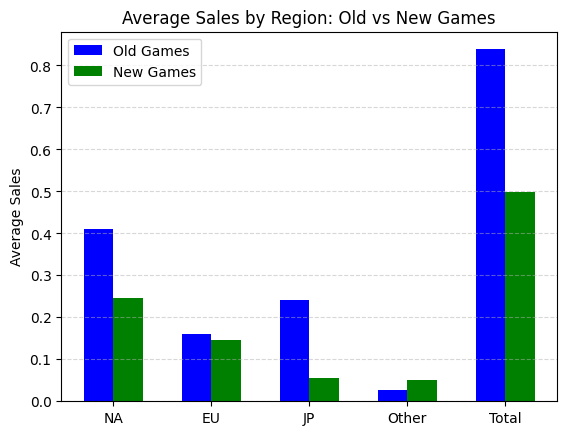

In [40]:
import matplotlib.pyplot as plt
import numpy as np

# regions
regions = ['NA', 'EU', 'JP', 'Other', 'Total']

# taking the averages of sales for each region's old and new games
old_means = [old_games_NA.mean(), old_games_EU.mean(), old_games_JP.mean(), old_games_other.mean(), sum_old_games.mean()]
new_means = [new_games_NA.mean(), new_games_EU.mean(), new_games_JP.mean(), new_games_other.mean(), sum_new_games.mean()]

# arrange the x positions by the regions
x = np.arange(len(regions))
width = 0.3

plt.figure()
# two bars split the size of one so the new and old avgs can be side to side & added legend labels and colors
plt.bar(x - width/2, old_means, width, label='Old Games', color='blue')
plt.bar(x + width/2, new_means, width, label='New Games', color='green')

# defines x axis labels
plt.xticks(x, regions)

# y positions
plt.ylabel("Average Sales")

plt.title("Average Sales by Region: Old vs New Games")
plt.legend()

# adds lines across graph for readability
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

The hypotheses for the t-test will be:

$H_0$ = There is no difference in sales between the old and new games.

$H_A$ = The sales are higher for older games.

We will test this using $α$ = 0.05.

This will be a right-tailed T-test since we are examining the larger (higher value/right) side of the graph.

In [41]:
# conversion to right-tailed p-value
p_right = 0
if t_stat_total > 0:
  p_right = p_value_total / 2
else:
  p_right = 1 - (p_value_total / 2)

print("Right-tailed P-Value:", p_right)

Right-tailed P-Value: 2.9621911226595467e-12


**Right-tailed T-test conclusion**: The p-value is less than 0.05 so we reject the null hypothesis and conclude that the sales do depend on the year. The right-tailed test specificially showed that the games made in the older years (1980-1999) produced higher sales than those made in the newer years (2000-2016).

# **Primary Analysis**
In the analysis phase, we have decided to use a Ridge regression model for predicting total sales of video games globally based on their correlation with game attributes as gathered during exploratory analysis due to its ability to allow for complex relationships to be classified as high dimensional. Looking at our data summary, the categorical features of 'Publisher' and 'Platform' were noted as being relevant but having large numbers of unique entries in those categories, so we used target encoding with smoothing to provide usable representations for these categorical variables in our Ridge regression model. Using this method, we will eliminate the added computational cost of using one-hot encoding and manage to avoid the high sparsity issue that one-hot encodes would cause.

We have employed TF-IDF Vectorization to enrich our prediction ability and capture the predictive power in video game titles. We have also used a TransformedTargetRegressor to perform a log transformation on global sales data; this log transformation is a mechanical requirement, as our initial examination revealed that data has a substantial right-skew due to “blockbuster” outliers, such as Wii Sports. Finally, rather than using standard linear regression models, we chose Ridge Regression at the same time that we were developing our model because of Ridge Regression’s regularization penalty, which is necessary to prevent our model from overfitting when there are thousands of engineered features in the dataset and provides for reproducibility, generalizability, and universality to an unknowledgeable reader.

In [42]:
df = df.dropna(subset=["Global_Sales"])
df["Name"] = df["Name"].fillna("")
df["Platform"] = df["Platform"].fillna("Unknown")
df["Genre"] = df["Genre"].fillna("Unknown")
df["Publisher"] = df["Publisher"].fillna("Unknown")
df["Year"] = pd.to_numeric(df["Year"], errors="coerce")

print(df.head())
print(df.shape)
def clean_name(name):
    name = str(name).lower()
    name = re.sub(r"[^a-z0-9 ]+", " ", name)
    name = re.sub(r"\s+", " ", name).strip()
    return name

df["Name_Clean"] = df["Name"].apply(clean_name)

df["First_Word"] = df["Name_Clean"].str.split().str[0].fillna("")
df["First_Two_Words"] = df["Name_Clean"].str.split().str[:2].str.join(" ").fillna("")

df["Platform_Genre"] = df["Platform"].astype(str) + "_" + df["Genre"].astype(str)
df["Publisher_Genre"] = df["Publisher"].astype(str) + "_" + df["Genre"].astype(str)
df["Platform_Publisher"] = df["Platform"].astype(str) + "_" + df["Publisher"].astype(str)

decade = (df["Year"] // 10) * 10
df["Decade"] = decade.astype("Int64").astype(str).replace("<NA>", "Unknown")

X = df[
    [
        "Name",
        "Name_Clean",
        "First_Word",
        "First_Two_Words",
        "Platform",
        "Year",
        "Genre",
        "Publisher",
        "Platform_Genre",
        "Publisher_Genre",
        "Platform_Publisher",
        "Decade"
    ]
]

y = df["Global_Sales"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

class GroupTargetEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, smoothing=30):
        self.smoothing = smoothing

    def fit(self, X, y):
        X = pd.DataFrame(X).copy()
        y = pd.Series(y).reset_index(drop=True)

        self.columns_ = X.columns.tolist()
        self.global_mean_ = y.mean()
        self.maps_ = {}

        for col in self.columns_:
            temp = pd.DataFrame({
                col: X[col].astype(str).reset_index(drop=True),
                "target": y
            })

            stats = temp.groupby(col)["target"].agg(["mean", "count"])

            smooth_mean = (
                (stats["mean"] * stats["count"] + self.global_mean_ * self.smoothing)
                / (stats["count"] + self.smoothing)
            )

            self.maps_[col] = smooth_mean.to_dict()

        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()

        encoded_columns = []

        for col in self.columns_:
            encoded = X[col].astype(str).map(self.maps_[col])
            encoded = encoded.fillna(self.global_mean_)
            encoded_columns.append(np.log1p(encoded).values)

        return np.column_stack(encoded_columns)

def smape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.maximum(np.array(y_pred), 0)

    numerator = np.abs(y_true - y_pred)
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2

    return np.mean(numerator / np.maximum(denominator, 1e-9)) * 100


def evaluate_model(y_true, y_pred, label):
    y_true = np.array(y_true)
    y_pred = np.maximum(np.array(y_pred), 0)

    absolute_errors = np.abs(y_true - y_pred)
    percent_errors = absolute_errors / np.maximum(y_true, 1e-9) * 100

    cutoff = np.percentile(percent_errors, 95)
    trimmed_percent_errors = percent_errors[percent_errors <= cutoff]

    mask_not_tiny = y_true >= 0.10
    percent_errors_not_tiny = percent_errors[mask_not_tiny]

    return {
        "Model": label,
        "MAE": mean_absolute_error(y_true, y_pred),
        "Median Absolute Error": median_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
        "Average Percent Error": np.mean(percent_errors),
        "Median Percent Error": np.median(percent_errors),
        "Trimmed Avg Percent Error": np.mean(trimmed_percent_errors),
        "Median Percent Error, Sales >= 0.10M": np.median(percent_errors_not_tiny),
        "SMAPE": smape(y_true, y_pred)
    }


categorical_features = [
    "Platform",
    "Genre",
    "Publisher",
    "Platform_Genre",
    "Publisher_Genre",
    "Platform_Publisher",
    "Decade",
    "First_Word",
    "First_Two_Words"
]

target_encoded_features = [
    "Platform",
    "Genre",
    "Publisher",
    "Platform_Genre",
    "Publisher_Genre",
    "Platform_Publisher",
    "Decade",
    "First_Word",
    "First_Two_Words"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "name_word_tfidf",
            TfidfVectorizer(min_df=2),
            "Name_Clean"
        ),
        (
            "name_char_tfidf",
            TfidfVectorizer(
                analyzer="char_wb",
                ngram_range=(3, 5),
                min_df=2
            ),
            "Name_Clean"
        ),
        (
            "categories",
            OneHotEncoder(handle_unknown="ignore", min_frequency=5),
            categorical_features
        ),
        (
            "target_encoded_history",
            Pipeline(
                steps=[
                    ("target_encoder", GroupTargetEncoder(smoothing=30)),
                    ("scaler", StandardScaler())
                ]
            ),
            target_encoded_features
        ),
        (
            "year",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler(with_mean=False))
                ]
            ),
            ["Year"]
        )
    ]
)

ridge_model = TransformedTargetRegressor(
    regressor=Ridge(solver="lsqr"),
    func=np.log1p,
    inverse_func=np.expm1
)

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", ridge_model)
    ]
)

   Rank                      Name Platform    Year         Genre Publisher  \
0     1                Wii Sports      Wii  2006.0        Sports  Nintendo   
1     2         Super Mario Bros.      NES  1985.0      Platform  Nintendo   
2     3            Mario Kart Wii      Wii  2008.0        Racing  Nintendo   
3     4         Wii Sports Resort      Wii  2009.0        Sports  Nintendo   
4     5  Pokemon Red/Pokemon Blue       GB  1996.0  Role-Playing  Nintendo   

   NA_Sales  EU_Sales  JP_Sales  Other_Sales  Global_Sales  
0     41.49     29.02      3.77         8.46         82.74  
1     29.08      3.58      6.81         0.77         40.24  
2     15.85     12.88      3.79         3.31         35.82  
3     15.75     11.01      3.28         2.96         33.00  
4     11.27      8.89     10.22         1.00         31.37  
(16290, 11)
(13032, 12)
(3258, 12)


In [43]:
# training parameters, shorten or longen train time here. minimal effect with more candidates

param_grid = {
    "preprocessor__name_word_tfidf__max_features": [1000, 3000, 5000],
    "preprocessor__name_word_tfidf__ngram_range": [(1, 2)],
    "preprocessor__name_char_tfidf__max_features": [1000, 3000],
    "regressor__regressor__alpha": [10, 30, 100]
}

grid = GridSearchCV(
    model,
    param_grid,
    scoring="neg_mean_absolute_error",
    cv=3,
    n_jobs=-1,
    verbose=2
)

grid.fit(X_train, y_train)

print("Best parameters:")
print(grid.best_params_)

best_model = grid.best_estimator_

Fitting 3 folds for each of 18 candidates, totalling 54 fits
Best parameters:
{'preprocessor__name_char_tfidf__max_features': 3000, 'preprocessor__name_word_tfidf__max_features': 5000, 'preprocessor__name_word_tfidf__ngram_range': (1, 2), 'regressor__regressor__alpha': 10}


In [44]:
y_pred = best_model.predict(X_test)
y_pred = np.maximum(y_pred, 0)

baseline_mean = DummyRegressor(strategy="mean")
baseline_median = DummyRegressor(strategy="median")

baseline_mean.fit(X_train, y_train)
baseline_median.fit(X_train, y_train)

baseline_mean_pred = baseline_mean.predict(X_test)
baseline_median_pred = baseline_median.predict(X_test)

results = []

results.append(evaluate_model(y_test, baseline_mean_pred, "Baseline Mean"))
results.append(evaluate_model(y_test, baseline_median_pred, "Baseline Median"))
results.append(evaluate_model(y_test, y_pred, "Improved Ridge + Target Encoding"))

results_df = pd.DataFrame(results)

print(results_df.to_string(index=False))
baseline_median_row = results_df[results_df["Model"] == "Baseline Median"].iloc[0]
model_row = results_df[results_df["Model"] == "Improved Ridge + Target Encoding"].iloc[0]

mae_improvement = (
    (baseline_median_row["MAE"] - model_row["MAE"])
    / baseline_median_row["MAE"]
) * 100

rmse_improvement = (
    (baseline_median_row["RMSE"] - model_row["RMSE"])
    / baseline_median_row["RMSE"]
) * 100

smape_improvement = (
    (baseline_median_row["SMAPE"] - model_row["SMAPE"])
    / baseline_median_row["SMAPE"]
) * 100

print("\nImprovement over Baseline Median:")
print("MAE improvement:", mae_improvement, "%")
print("RMSE improvement:", rmse_improvement, "%")
print("SMAPE improvement:", smape_improvement, "%")

                           Model      MAE  Median Absolute Error     RMSE        R2  Average Percent Error  Median Percent Error  Trimmed Avg Percent Error  Median Percent Error, Sales >= 0.10M      SMAPE
                   Baseline Mean 0.620984               0.424401 2.069189 -0.000250             680.955670            234.000921                 510.984989                             83.194922 109.763447
                 Baseline Median 0.497010               0.130000 2.106696 -0.036841             200.269011             78.481013                 148.130034                             55.263158  93.182349
Improved Ridge + Target Encoding 0.422319               0.170687 1.875710  0.178061             280.890855             75.974676                 164.036130                             53.683199  85.200032

Improvement over Baseline Median:
MAE improvement: 15.02818851662447 %
RMSE improvement: 10.964375175869122 %
SMAPE improvement: 8.566341070533328 %


In [45]:
comparison = X_test.copy()

comparison["Actual_Global_Sales"] = y_test.values
comparison["Predicted_Global_Sales"] = y_pred
comparison["Absolute_Error"] = np.abs(
    comparison["Actual_Global_Sales"] - comparison["Predicted_Global_Sales"]
)

comparison["Percent_Error"] = (
    comparison["Absolute_Error"] / comparison["Actual_Global_Sales"]
) * 100

print(
    comparison[
        [
            "Name",
            "Platform",
            "Year",
            "Genre",
            "Publisher",
            "Actual_Global_Sales",
            "Predicted_Global_Sales",
            "Absolute_Error",
            "Percent_Error"
        ]
    ].sample(15, random_state=1).to_string(index=False)
)

                                           Name Platform   Year        Genre                    Publisher  Actual_Global_Sales  Predicted_Global_Sales  Absolute_Error  Percent_Error
                    James Bond 007: Blood Stone       DS 2010.0      Shooter                   Activision                 0.07                0.304128        0.234128     334.469254
                         Murdered: Soul Suspect     X360 2014.0       Action                  Square Enix                 0.11                0.276479        0.166479     151.344803
  The Legend of Heroes: Trails of Cold Steel II      PS3 2014.0 Role-Playing         Nippon Ichi Software                 0.12                0.468858        0.348858     290.715204
                            Pac-Man World Rally      PSP 2006.0       Racing           Namco Bandai Games                 0.04                0.323304        0.283304     708.258810
                Commandos 3: Destination Berlin       PC 2003.0     Strategy            Ei

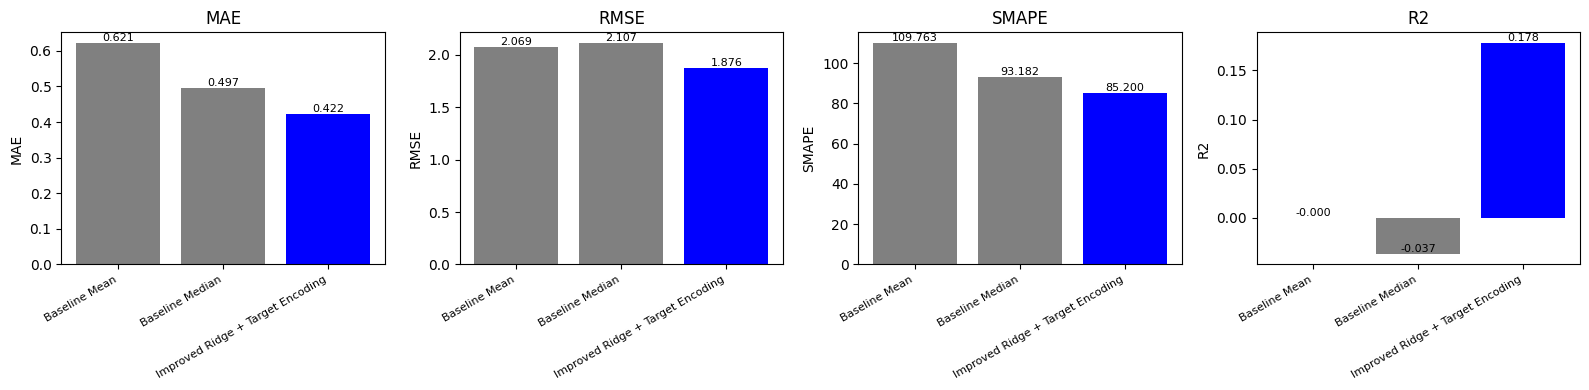

In [46]:
metrics_to_plot = ["MAE", "RMSE", "SMAPE", "R2"]

plt.figure(figsize=(16, 4))
for i, metric in enumerate(metrics_to_plot):
    plt.subplot(1, 4, i + 1)
    colors = ["gray", "gray", "blue"]
    bars = plt.bar(results_df["Model"], results_df[metric], color=colors)
    plt.title(metric)
    plt.ylabel(metric)
    plt.xticks(rotation=30, ha="right", fontsize=8)
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width() / 2, height,
                 f"{height:.3f}", ha="center", va="bottom", fontsize=8)
plt.tight_layout()
plt.show()

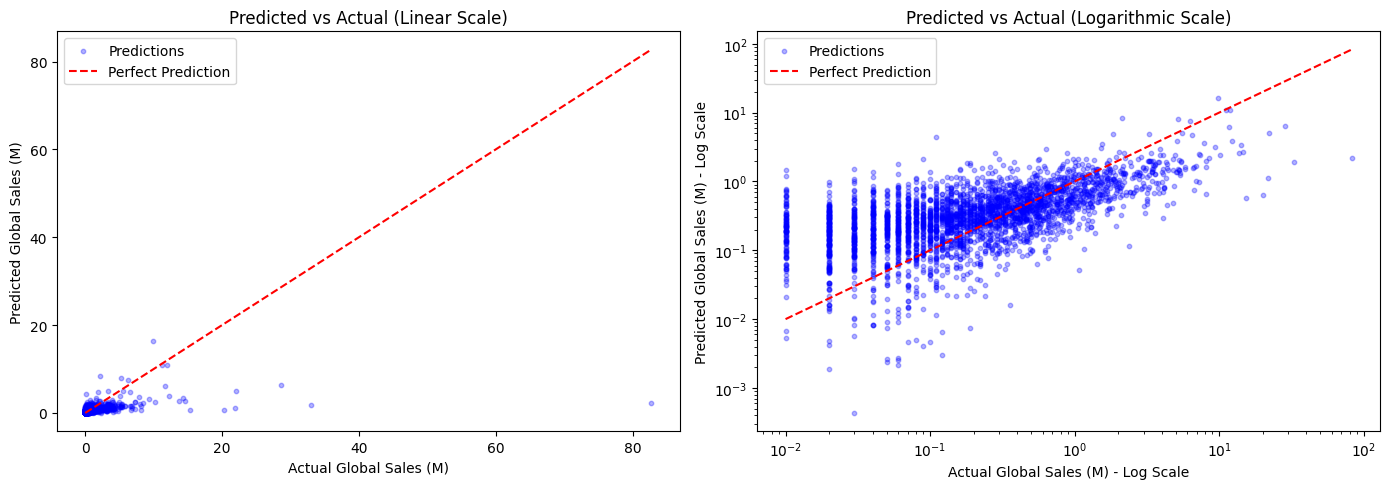

In [47]:
plt.figure(figsize=(14, 5))

# Linear scale
plt.subplot(1, 2, 1)
plt.scatter(comparison["Actual_Global_Sales"],
            comparison["Predicted_Global_Sales"],
            alpha=0.3, s=10, color="blue", label="Predictions")
max_val = max(comparison["Actual_Global_Sales"].max(),
              comparison["Predicted_Global_Sales"].max())
plt.plot([0, max_val], [0, max_val], color="red", linestyle="--", label="Perfect Prediction")
plt.xlabel("Actual Global Sales (M)")
plt.ylabel("Predicted Global Sales (M)")
plt.title("Predicted vs Actual (Linear Scale)")
plt.legend()

# Log scale
plt.subplot(1, 2, 2)
plt.scatter(comparison["Actual_Global_Sales"],
            comparison["Predicted_Global_Sales"],
            alpha=0.3, s=10, color="blue", label="Predictions")
plt.plot([0.01, max_val], [0.01, max_val], color="red", linestyle="--", label="Perfect Prediction")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Actual Global Sales (M) - Log Scale")
plt.ylabel("Predicted Global Sales (M) - Log Scale")
plt.title("Predicted vs Actual (Logarithmic Scale)")
plt.legend()

plt.tight_layout()
plt.show()

**Description and Insights**

This visualization compares the model’s predictions against the actual sales figures.

*   The Red Dashed Line: Where the predicted value and the actual value are exactly the same, in other words the "Perfect Prediction".
*   Linear Scale (Left Chart): Shows a general trend of the model's fit but does have trouble predicting the "blockbuster" level of sales (i.e. Games that sold over 10 million copies). The majority of data points are located at the origin of the graph, which makes it difficult to evaluate the performance of these models on the lower selling games.
*   Logarithmic Scale (Right Chart): Because we look at the model against the log scale, we can evaluate how well the model is performing relative to all other levels of success. Although the mid range games have significant concentration of data points around the red solid line on the graph, this indicates that Ridge Regression Model does a very good job of predicting what an "average" Game may look like. However, it has limitations in estimating what would be the next "Wii Sports" or "Grand Theft Auto" based on the "Wii Sports" and/or "Grand Theft Auto".

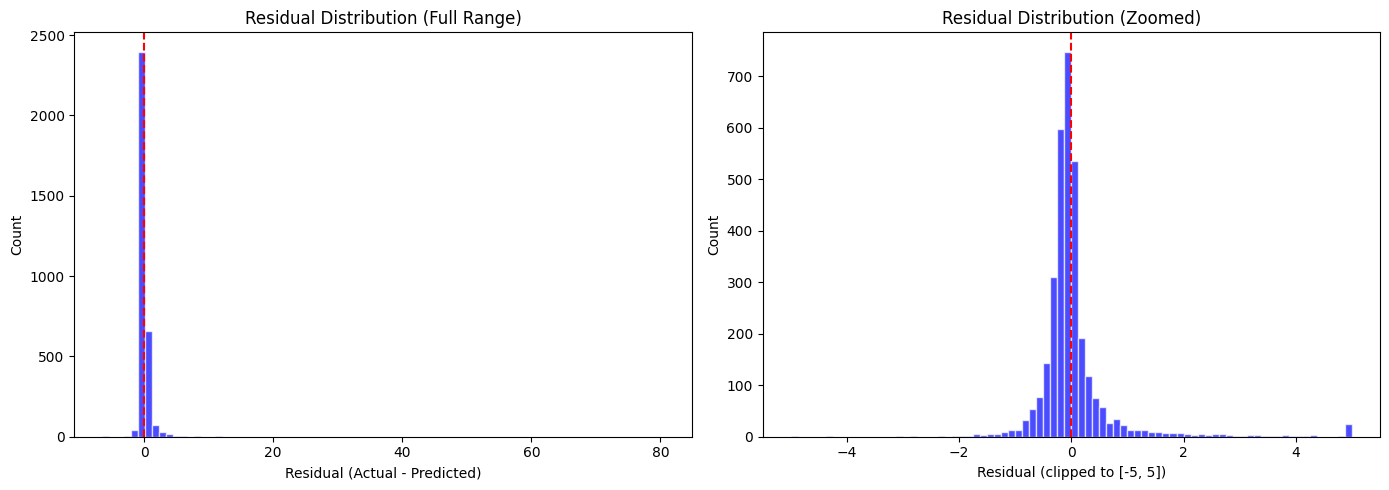

Residual Mean:   0.1050
Residual Median: -0.0669
Residual Std:    1.8731


In [48]:
residuals = comparison["Actual_Global_Sales"] - comparison["Predicted_Global_Sales"]

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.hist(residuals, bins=80, color="blue", edgecolor="white", alpha=0.7)
plt.axvline(0, color="red", linestyle="--")
plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Count")
plt.title("Residual Distribution (Full Range)")

plt.subplot(1, 2, 2)
clipped = residuals.clip(-5, 5)
plt.hist(clipped, bins=80, color="blue", edgecolor="white", alpha=0.7)
plt.axvline(0, color="red", linestyle="--")
plt.xlabel("Residual (clipped to [-5, 5])")
plt.ylabel("Count")
plt.title("Residual Distribution (Zoomed)")

plt.tight_layout()
plt.show()

print(f"Residual Mean:   {residuals.mean():.4f}")
print(f"Residual Median: {residuals.median():.4f}")
print(f"Residual Std:    {residuals.std():.4f}")


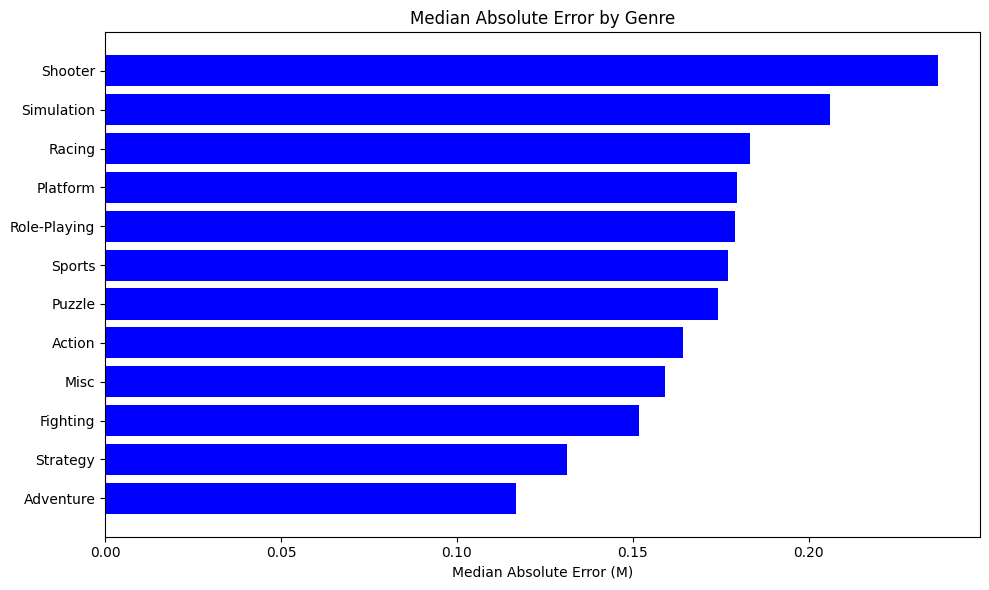

In [49]:
genre_errors = comparison.groupby("Genre")["Absolute_Error"].median().sort_values()

plt.figure(figsize=(10, 6))
plt.barh(genre_errors.index, genre_errors.values, color="blue")
plt.xlabel("Median Absolute Error (M)")
plt.title("Median Absolute Error by Genre")
plt.tight_layout()
plt.show()

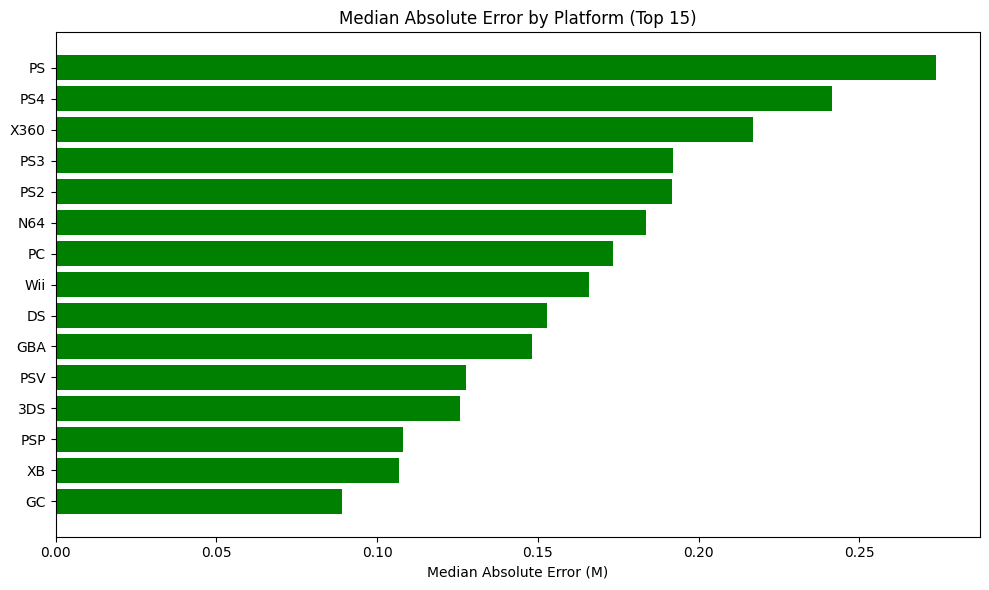

In [50]:
platform_counts = comparison.groupby("Platform")["Absolute_Error"].count()
top_platforms = platform_counts.nlargest(15).index
platform_errors = comparison[comparison["Platform"].isin(top_platforms)] \
    .groupby("Platform")["Absolute_Error"].median().sort_values()

plt.figure(figsize=(10, 6))
plt.barh(platform_errors.index, platform_errors.values, color="green")
plt.xlabel("Median Absolute Error (M)")
plt.title("Median Absolute Error by Platform (Top 15)")
plt.tight_layout()
plt.show()


=== Performance by Sales Bucket ===
Sales_Bucket  Count  Median_AE  Median_Pct_Error
      <0.05M    720   0.129214        461.189295
   0.05-0.1M    501   0.129072        170.807555
    0.1-0.5M   1280   0.140220         59.395086
      0.5-1M    378   0.270200         38.963293
        1-5M    332   0.836943         51.627866
         5M+     47   5.100741         73.722197


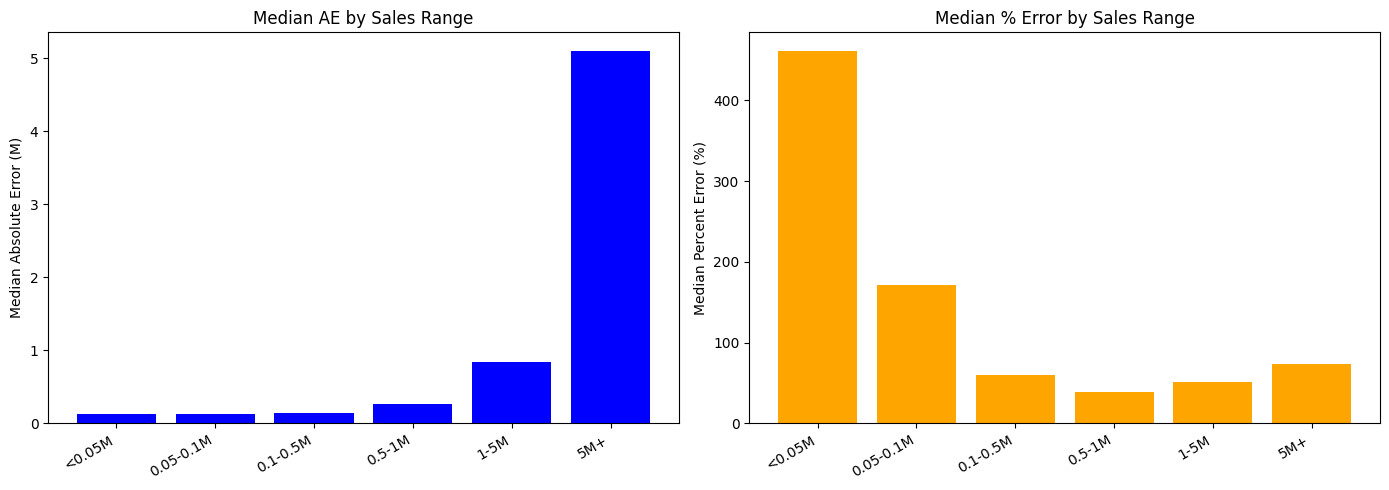

In [51]:
bins = [0, 0.05, 0.1, 0.5, 1, 5, 100]
labels = ["<0.05M", "0.05-0.1M", "0.1-0.5M", "0.5-1M", "1-5M", "5M+"]

comparison["Sales_Bucket"] = pd.cut(
    comparison["Actual_Global_Sales"],
    bins=bins, labels=labels, include_lowest=True
)

bucket_stats = comparison.groupby("Sales_Bucket", observed=False).agg(
    Count=("Absolute_Error", "count"),
    Median_AE=("Absolute_Error", "median"),
    Median_Pct_Error=("Percent_Error", "median")
).reset_index()

print("\n=== Performance by Sales Bucket ===")
print(bucket_stats.to_string(index=False))

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.bar(bucket_stats["Sales_Bucket"].astype(str), bucket_stats["Median_AE"], color="blue")
plt.ylabel("Median Absolute Error (M)")
plt.title("Median AE by Sales Range")
plt.xticks(rotation=30, ha="right")

plt.subplot(1, 2, 2)
plt.bar(bucket_stats["Sales_Bucket"].astype(str), bucket_stats["Median_Pct_Error"], color="orange")
plt.ylabel("Median Percent Error (%)")
plt.title("Median % Error by Sales Range")
plt.xticks(rotation=30, ha="right")

plt.tight_layout()
plt.show()


**Description and Insights**

To truly understand where our model succeeds, we binned games by their actual sales volume.

*    Median Absolute Error (Left): For games with less than 0.05M in sales, our error is minimal (almost zero). However, the absolute error increases with sales.
*    Median Percent Error (Right): This serves as an additional "reality check". While the absolute error is low for small games, their percentage errors can be quite high (over 60%). Therefore, the model can best predict mid-to-top tier titles (0.5M - 5M), where the percentage errors greatly decrease. This implies that the features used for modelling (platform, genre, keyword within title) do a better job of indicating a "hit" game rather than a "niche" game.

In [52]:
print("\n=== Top 10 Most Accurate Predictions ===")
best = comparison.nsmallest(10, "Absolute_Error")[
    ["Name", "Platform", "Genre", "Actual_Global_Sales", "Predicted_Global_Sales", "Absolute_Error"]
]
print(best.to_string(index=False))

print("\n=== Top 10 Worst Predictions ===")
worst = comparison.nlargest(10, "Absolute_Error")[
    ["Name", "Platform", "Genre", "Actual_Global_Sales", "Predicted_Global_Sales", "Absolute_Error"]
]
print(worst.to_string(index=False))


=== Top 10 Most Accurate Predictions ===
                                                                        Name Platform      Genre  Actual_Global_Sales  Predicted_Global_Sales  Absolute_Error
                                          Nobunaga's Ambition: Rise to Power      PS2   Strategy                 0.08                0.079770        0.000230
                                                                 System Flaw       DS    Shooter                 0.10                0.099662        0.000338
                                                                    FabStyle       DS   Strategy                 0.08                0.080403        0.000403
                                           Dance Dance Revolution Universe 2     X360 Simulation                 0.50                0.499291        0.000709
Famicom Mini: Famicom Tantei Club Part II - Ushiro ni Tatsu Shoujo Zenkouhen      GBA  Adventure                 0.10                0.100752        0.000752
          

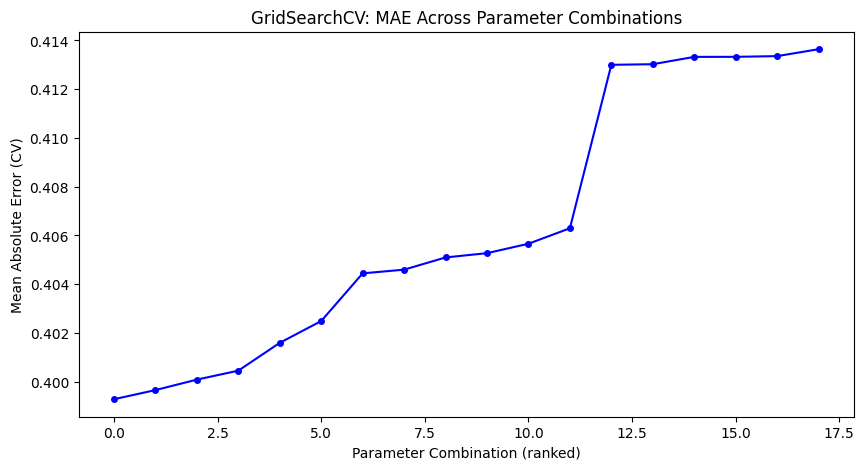

Best Parameters: {'preprocessor__name_char_tfidf__max_features': 3000, 'preprocessor__name_word_tfidf__max_features': 5000, 'preprocessor__name_word_tfidf__ngram_range': (1, 2), 'regressor__regressor__alpha': 10}
Best CV MAE: 0.3992810405112642


In [53]:
cv_results = pd.DataFrame(grid.cv_results_)
cv_results_sorted = cv_results.sort_values("rank_test_score")

plt.figure(figsize=(10, 5))
scores = -cv_results_sorted["mean_test_score"].values  # neg MAE -> positive
plt.plot(range(len(scores)), scores, color="blue", marker="o", markersize=4)
plt.xlabel("Parameter Combination (ranked)")
plt.ylabel("Mean Absolute Error (CV)")
plt.title("GridSearchCV: MAE Across Parameter Combinations")
plt.show()

print("Best Parameters:", grid.best_params_)
print("Best CV MAE:", -grid.best_score_)

# **Insights and Conclusion**

Through this project, a reader that has little knowledge of gaming can understand how commercial successes of video games are actually generated. The evaluative process successfully connects numerical data to trends in the industry by illustrating that video games are not successful due to luck; rather, there is a significant correlation between commercial success and the types of genres, platforms and the timing when the game was created. The findings of the ANOVA proved that there are two types (Shooter and Platformer) of genres that consistently perform better than other categories (e.g., Racing, Discussion, and Adventure). The second part of the overall analysis shows that the collection of T-tests suggested that older video games had higher average sales per video game than more recent games. The overall analysis provides a clear narrative of how the market has changed over time in relation to video games. Finally, a reader new to video gaming will end this project with a sense of knowledge explaining; while "viral hits" are very difficult to identify, combinations of branding of the video game (based on the TF-IDF method of analyzing the titles gives) and having the support of an established publisher predictably expected to lead video games to commercial success statistically.

This project represents an analysis of the gaming industry that goes beyond conventional "gamer" wisdom. Those who are intimately involved with the gaming industry probably know which game types and console manufacturers have high sales; however, the Tukey HSD post-hoc test provides exact sales rankings of game type, based on statistical criteria. Additionally, using the machine learning model provides an understanding of the "predictive weight" of the titles and publishers tested. Also, the "Sales Bucket" section of the analysis provides an informative perspective for an experienced reader in that it shows the model's capabilities in predicting mid-level success, and some of the inherent trouble modeling 10M+ games that frequently use external marketing and/or social use factors to achieve success. In conclusion, this study provides an informative and analytical view of the industry that should be of value to anyone with experience in the gaming industry.